In [3]:
import os
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt
import pathlib as Path

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

from src.datasets.visium_loader import load_visium
adata = load_visium(cfg)

print(adata)

Loading cached AnnData from data\processed\adata_raw.h5ad
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [4]:
# calculate QC metrics

# flag mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True,
    log1p=False,
)

print("QC columns added to obs:")
print([c for c in adata.obs.columns if c not in ["in_tissue", "array_row", "array_col"]])
print("\nSummary:")
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe().round(2))

QC columns added to obs:
['n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt']

Summary:
       total_counts  n_genes_by_counts  pct_counts_mt
count       3798.00            3798.00        3798.00
mean       21814.71            5621.99           4.01
std        13822.86            2085.86           1.83
min          578.00             430.00           1.12
25%        10201.75            4053.00           2.76
50%        20761.50            6026.50           3.50
75%        30463.25            7276.00           4.68
max        81624.00           10153.00          14.42


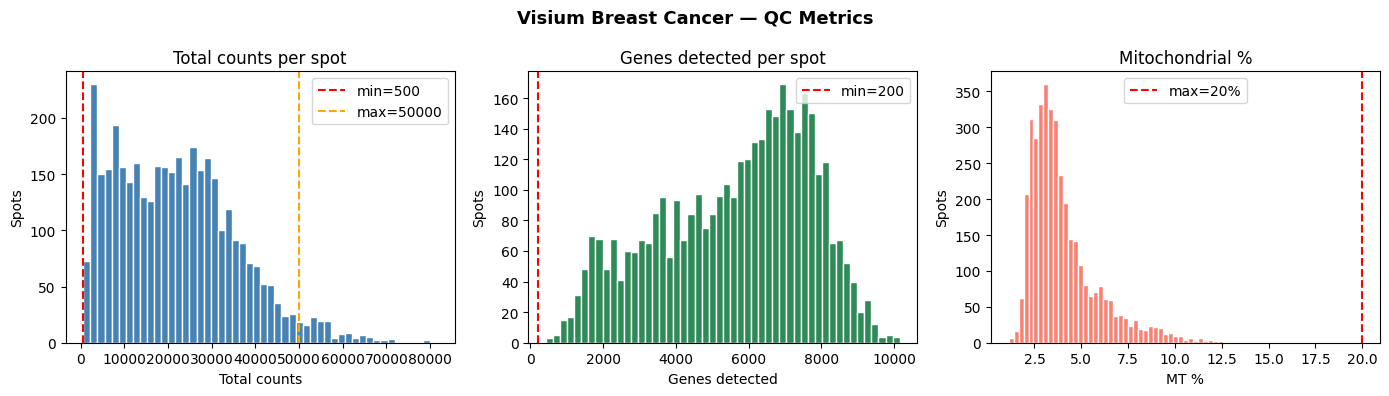

Saved: figures/evaluation/qc_distributions.png


In [7]:
# visualize QC distributions
from pathlib import Path as P

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(adata.obs["total_counts"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(cfg["qc"]["min_counts"], color="red", linestyle="--", label=f'min={cfg["qc"]["min_counts"]}')
axes[0].axvline(cfg["qc"]["max_counts"], color="orange", linestyle="--", label=f'max={cfg["qc"]["max_counts"]}')
axes[0].set_xlabel("Total counts")
axes[0].set_ylabel("Spots")
axes[0].set_title("Total counts per spot")
axes[0].legend()

axes[1].hist(adata.obs["n_genes_by_counts"], bins=50, color="seagreen", edgecolor="white")
axes[1].axvline(cfg["qc"]["min_genes"], color="red", linestyle="--", label=f'min={cfg["qc"]["min_genes"]}')
axes[1].set_xlabel("Genes detected")
axes[1].set_ylabel("Spots")
axes[1].set_title("Genes detected per spot")
axes[1].legend()

axes[2].hist(adata.obs["pct_counts_mt"], bins=50, color="salmon", edgecolor="white")
axes[2].axvline(cfg["qc"]["max_pct_mt"], color="red", linestyle="--", label=f'max={cfg["qc"]["max_pct_mt"]}%')
axes[2].set_xlabel("MT %")
axes[2].set_ylabel("Spots")
axes[2].set_title("Mitochondrial %")
axes[2].legend()

plt.suptitle("Visium Breast Cancer — QC Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()

P("figures/evaluation").mkdir(parents=True, exist_ok=True)
plt.savefig("figures/evaluation/qc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/evaluation/qc_distributions.png")

In [8]:
# apply the filters

print("Spots before QC:", adata.n_obs)

adata = adata[
    (adata.obs["total_counts"] >= cfg["qc"]["min_counts"]) &
    (adata.obs["total_counts"] <= cfg["qc"]["max_counts"]) &
    (adata.obs["n_genes_by_counts"] >= cfg["qc"]["min_genes"]) &
    (adata.obs["pct_counts_mt"] <= cfg["qc"]["max_pct_mt"])
].copy()

sc.pp.filter_genes(adata, min_cells=cfg["qc"]["min_cells"])

print("Spots after QC :", adata.n_obs)
print("Genes after QC :", adata.n_vars)

Spots before QC: 3798
Spots after QC : 3661
Genes after QC : 20955


In [9]:
# save QC-filtered object

adata.write_h5ad("data/processed/adata_qc.h5ad")

print("Spots: ", adata.n_obs)
print("Genes: ", adata.n_vars)
print("Saved: data/processed/adata_qc.h5ad")

Spots:  3661
Genes:  20955
Saved: data/processed/adata_qc.h5ad


In [10]:
# write_qc_module

qc_code = '''from __future__ import annotations
from  typing import Any
import scanpy as sc 
import anndata as ad

def run_qc(adata: ad.AnnData, cfg: dict[str, Any]) -> ad.AnnData:
    """
    Flag mitochondrial genes, compute QC metrics, filter spots and genes.

    Parameters
    ----------
    adata : AnnData  Raw count matrix.
    cfg   : dict     Master config (uses cfg["qc"] thresholds).

    Returns
    -------
    AnnData  Filtered copy with QC metrics stored in .obs.
    """
    qc = cfg["qc"]

    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)

    mask = (
        (adata.obs["total_counts"]      >= qc["min_counts"]) &
        (adata.obs["total_counts"]      <= qc["max_counts"]) &
        (adata.obs["n_genes_by_counts"] >= qc["min_genes"]) &
        (adata.obs["pct_counts_mt"]     <= qc["max_pct_mt"])
    )
    adata = adata[mask].copy()
    sc.pp.filter_genes(adata, min_cells=qc["min_cells"])

    return adata
'''

with open("src/preprocessing/quality_control.py", "w") as f:
    f.write(qc_code)

print("Created: src/preprocessing/quality_control.py")

Created: src/preprocessing/quality_control.py
